In [1]:
import os
import shutil
import pandas as pd

# Load df to ensure it's available in this execution context
# df = pd.read_csv('/content/drive/MyDrive/Thesis_folder/CSV_Files/mammo-bench.csv')
# df = pd.read_csv('D:\Thesis_folder\mammobench\Mammo_Bench_v2\CSV_Files\mammo-bench.csv')
df = pd.read_csv('D:\Thesis_folder\Dataset_folder\mammobench\Mammo_Bench_v2\CSV_Files\mammo-bench.csv')
print(df)
output_base_dir = "D:/Thesis_folder/classification_folders"
os.makedirs(output_base_dir, exist_ok=True)
print(os.path.exists(output_base_dir))
# Get unique classification types
classifications = df['classification'].unique()

# Create subfolders for each classification
for class_name in classifications:
    class_folder = os.path.join(output_base_dir, class_name.replace(' ', '_'))
    os.makedirs(os.path.join(class_folder, 'raw_images'), exist_ok=True)
    os.makedirs(os.path.join(class_folder, 'preprocessed_images'), exist_ok=True)
    os.makedirs(os.path.join(class_folder, 'new_preprocessed_images'), exist_ok=True)
    print(f"Created folders for: {class_name}")

print("Folder structure created successfully.")

      source_dataset                       preprocessed_image_path  \
0           inbreast  Preprocessed_Dataset/inbreast/inbreast_0.jpg   
1           inbreast  Preprocessed_Dataset/inbreast/inbreast_1.jpg   
2           inbreast  Preprocessed_Dataset/inbreast/inbreast_2.jpg   
3           inbreast  Preprocessed_Dataset/inbreast/inbreast_3.jpg   
4           inbreast  Preprocessed_Dataset/inbreast/inbreast_4.jpg   
...              ...                                           ...   
19726           ddsm      Preprocessed_Dataset/ddsm/ddsm_10395.jpg   
19727           ddsm      Preprocessed_Dataset/ddsm/ddsm_10396.jpg   
19728           ddsm      Preprocessed_Dataset/ddsm/ddsm_10397.jpg   
19729           ddsm      Preprocessed_Dataset/ddsm/ddsm_10398.jpg   
19730           ddsm      Preprocessed_Dataset/ddsm/ddsm_10399.jpg   

      classification density  BIRADS                      mask_path  \
0             Normal       D     1.0  Masks/inbreast/inbreast_0.jpg   
1             Ben

In [2]:
df.head(10)

,source_dataset,preprocessed_image_path,classification,density,BIRADS,mask_path,raw_image_path,laterality,view,source_subjectID,...,x,y,radius,abnormality id,calc type,calc distribution,subtlety,mass shape,mass margins,cropped_image_file_new
0,inbreast,Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,D,1.0,Masks/inbreast/inbreast_0.jpg,Original_Dataset/inbreast/inbreast_0.jpg,R,CC,22678622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,inbreast,Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,D,3.0,Masks/inbreast/inbreast_1.jpg,Original_Dataset/inbreast/inbreast_1.jpg,L,CC,22678646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,inbreast,Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,D,1.0,Masks/inbreast/inbreast_2.jpg,Original_Dataset/inbreast/inbreast_2.jpg,R,MLO,22678670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,inbreast,Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,D,3.0,Masks/inbreast/inbreast_3.jpg,Original_Dataset/inbreast/inbreast_3.jpg,L,MLO,22678694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,inbreast,Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,B,5.0,Masks/inbreast/inbreast_4.jpg,Original_Dataset/inbreast/inbreast_4.jpg,R,CC,22614074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,inbreast,Preprocessed_Dataset/inbreast/inbreast_5.jpg,Benign,B,2.0,Masks/inbreast/inbreast_5.jpg,Original_Dataset/inbreast/inbreast_5.jpg,L,CC,22614097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,inbreast,Preprocessed_Dataset/inbreast/inbreast_6.jpg,Malignant,B,5.0,Masks/inbreast/inbreast_6.jpg,Original_Dataset/inbreast/inbreast_6.jpg,R,MLO,22614127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,inbreast,Preprocessed_Dataset/inbreast/inbreast_7.jpg,Benign,B,2.0,Masks/inbreast/inbreast_7.jpg,Original_Dataset/inbreast/inbreast_7.jpg,L,MLO,22614150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,inbreast,Preprocessed_Dataset/inbreast/inbreast_8.jpg,Benign,C,2.0,Masks/inbreast/inbreast_8.jpg,Original_Dataset/inbreast/inbreast_8.jpg,L,MLO,50997434,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,inbreast,Preprocessed_Dataset/inbreast/inbreast_9.jpg,Suspicious Malignant,C,4.0,Masks/inbreast/inbreast_9.jpg,Original_Dataset/inbreast/inbreast_9.jpg,R,MLO,50997461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(19731, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19731 entries, 0 to 19730
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   source_dataset           19731 non-null  object 
 1   preprocessed_image_path  19731 non-null  object 
 2   classification           19731 non-null  object 
 3   density                  14441 non-null  object 
 4   BIRADS                   4097 non-null   float64
 5   mask_path                19731 non-null  object 
 6   raw_image_path           19731 non-null  object 
 7   laterality               19731 non-null  object 
 8   view                     19730 non-null  object 
 9   source_subjectID         19731 non-null  object 
 10  original_source_path     19731 non-null  object 
 11  subject_age              18811 non-null  float64
 12  abnormality              5712 non-null   object 
 13  molecular_subtype        2956 non-null   object 
 14  ROI_path              

In [5]:
unique_datasets = df['source_dataset'].unique()
for i in unique_datasets:
    print(i)

inbreast
kau-bcmd
cmmd
cdd-cesm
dmid
ddsm


In [6]:
df.isnull().sum()

source_dataset                 0
preprocessed_image_path        0
classification                 0
density                     5290
BIRADS                     15634
mask_path                      0
raw_image_path                 0
laterality                     0
view                           1
source_subjectID               0
original_source_path           0
subject_age                  920
abnormality                14019
molecular_subtype          16775
ROI_path                   19462
x                          19423
y                          19423
radius                     19425
abnormality id             19731
calc type                  19731
calc distribution          19731
subtlety                   19731
mass shape                 19731
mass margins               19731
cropped_image_file_new     19731
dtype: int64

In [7]:
# Extract dataset name from path
df['source_dataset'] = ""
for i in range(len(df)):
    path = str(df.loc[i,"raw_image_path"])
    parts = path.split('/')
    if len(parts) > 1:
        df.loc[i,'source_dataset'] = parts[1]
    else:
        df.loc[i,'source_dataset'] = "Unknown"
print(df[['raw_image_path','source_dataset']].head(10))

                             raw_image_path source_dataset
0  Original_Dataset/inbreast/inbreast_0.jpg       inbreast
1  Original_Dataset/inbreast/inbreast_1.jpg       inbreast
2  Original_Dataset/inbreast/inbreast_2.jpg       inbreast
3  Original_Dataset/inbreast/inbreast_3.jpg       inbreast
4  Original_Dataset/inbreast/inbreast_4.jpg       inbreast
5  Original_Dataset/inbreast/inbreast_5.jpg       inbreast
6  Original_Dataset/inbreast/inbreast_6.jpg       inbreast
7  Original_Dataset/inbreast/inbreast_7.jpg       inbreast
8  Original_Dataset/inbreast/inbreast_8.jpg       inbreast
9  Original_Dataset/inbreast/inbreast_9.jpg       inbreast


In [8]:
print(df['source_dataset'].value_counts())

source_dataset
ddsm        10400
cmmd         5202
kau-bcmd     2206
cdd-cesm     1003
dmid          510
inbreast      410
Name: count, dtype: int64


In [14]:
print("start")
import os
import random
import shutil
random.seed(42)
# source_dataset = r'D:\Thesis_folder\Dataset_folder\classification_folders'
# balanced_dataset = r'D:\Thesis_folder\Dataset_folder\new_balanced_dataset'
class_paths = {
    "Malignant": r"D:\Thesis_folder\Dataset_folder\classification_folders\Malignant\raw_images",
    "Benign": r"D:\Thesis_folder\Dataset_folder\classification_folders\Benign\raw_images",
    "Normal": r"D:\Thesis_folder\Dataset_folder\classification_folders\Normal\raw_images",
    "Suspicious_Malignant": r"D:\Thesis_folder\Dataset_folder\classification_folders\Suspicious_Malignant\raw_images"
}
balanced_dataset = r"D:\Thesis_folder\Balanced_dataset"
target_counts = {
    "Malignant":6500,
    "Benign":5069,
    "Normal":4493,
    "Suspicious_Malignant":235
}
os.makedirs(balanced_dataset,exist_ok=True)
valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
for cls in class_paths:
    src = class_paths[cls]
    dst = os.path.join(balanced_dataset,cls)
    os.makedirs(dst,exist_ok=True)
    images = [
        f for f in os.listdir(src)
        if f.lower().endswith(valid_extensions)
    ]
    print(f"{cls}:Found {len(images)} images")
    if len(images) > target_counts[cls]:
        images = random.sample(images,target_counts[cls])
    for img in images:
        shutil.copy2(
            os.path.join(src,img),
            os.path.join(dst,img)
        )
print("Undersampling finished.")

start
Malignant:Found 8184 images
Benign:Found 6069 images
Normal:Found 5243 images
Suspicious_Malignant:Found 235 images
Undersampling finished.


In [15]:

import os

root = r"D:\Thesis_folder\new_undersampling_dataset"

total = 0

for cls in os.listdir(root):
    folder = os.path.join(root, cls)

    if os.path.isdir(folder):
        n = len([
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f))
        ])
        print(f"{cls}: {n}")
        total += n

print("-" * 30)
print("Total:", total)
    

Benign: 5069
Malignant: 6500
Normal: 4493
Suspicious_Malignant: 235
------------------------------
Total: 16297


In [2]:
import os
import cv2
import random
import albumentations as A
from tqdm import tqdm


random.seed(42)


# =====================================================
# PATHS
# =====================================================

# Original Suspicious Malignant folder
source_folder = r"D:\Thesis_folder\Dataset_folder\classification_folders\Suspicious_Malignant\raw_images"


# Output augmented folder
output_folder = r"D:\Thesis_folder\new_undersampling_dataset\Suspicious_Malignant2"


os.makedirs(output_folder, exist_ok=True)



# =====================================================
# TARGET NUMBER OF IMAGES
# =====================================================

target_count = 1000



# =====================================================
# IMAGE EXTENSIONS
# =====================================================

valid_extensions = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
)



# =====================================================
# LOAD ORIGINAL IMAGES
# =====================================================

images = [
    f for f in os.listdir(source_folder)
    if f.lower().endswith(valid_extensions)
]


print("Original Suspicious Malignant images:", len(images))



# =====================================================
# COPY ORIGINAL IMAGES
# =====================================================

for img in tqdm(images, desc="Copying original images"):

    src = os.path.join(
        source_folder,
        img
    )

    dst = os.path.join(
        output_folder,
        img
    )

    image = cv2.imread(src)

    cv2.imwrite(
        dst,
        image
    )



current_count = len(images)



# =====================================================
# CHECK IMAGE SIZE
# =====================================================

sample_image = cv2.imread(
    os.path.join(source_folder, images[0])
)


height, width = sample_image.shape[:2]


print("Original image size:", height, width)



# =====================================================
# AUGMENTATION PIPELINE BASED ON PAPER
# =====================================================


augmentation = A.Compose([


    # -----------------------------------------------
    # 1. Rotation (±10 degrees)
    # -----------------------------------------------

    A.Rotate(
        limit=10,
        p=0.5
    ),



    # -----------------------------------------------
    # 2. Zoom (0.90 - 1.10)
    # -----------------------------------------------

    A.Affine(
        scale=(0.90,1.10),
        p=0.5
    ),



    # -----------------------------------------------
    # 3. Translation (±10%)
    # -----------------------------------------------

    A.Affine(
        translate_percent=(-0.10,0.10),
        p=0.5
    ),



    # -----------------------------------------------
    # 4. Contrast Adjustment (0.90 - 1.10)
    # -----------------------------------------------

    A.RandomBrightnessContrast(
        brightness_limit=0,
        contrast_limit=0.10,
        p=0.5
    ),



    # -----------------------------------------------
    # 5. Random Crop 500x500
    # If image is large enough
    # -----------------------------------------------

    A.RandomCrop(
        height=min(500,height),
        width=min(500,width),
        p=0.5
    ),



    # Resize for CNN input
    # (EfficientNetB3/InceptionV3)
    A.Resize(
        height=224,
        width=224
    ),



    # -----------------------------------------------
    # 6. Elastic Transformation
    # -----------------------------------------------

    A.ElasticTransform(
        alpha=2,
        sigma=50,
        p=0.3
    ),



    # -----------------------------------------------
    # 7. Gaussian Noise
    # Mean=0, Std=3
    # -----------------------------------------------

    A.GaussNoise(
        std_range=(3/255,3/255),
        p=0.3
    )


])



# =====================================================
# GENERATE AUGMENTED IMAGES
# =====================================================


print("\nGenerating augmented images...")


progress = tqdm(
    total=target_count-current_count
)



while current_count < target_count:


    # Randomly select original image

    img_name = random.choice(images)


    img_path = os.path.join(
        source_folder,
        img_name
    )


    image = cv2.imread(
        img_path
    )


    # Apply augmentation

    augmented = augmentation(
        image=image
    )


    aug_image = augmented["image"]



    # New filename

    new_name = (
        f"aug_{current_count}_{img_name}"
    )


    save_path = os.path.join(
        output_folder,
        new_name
    )


    cv2.imwrite(
        save_path,
        aug_image
    )


    current_count += 1


    progress.update(1)



progress.close()



print("\n================================")
print("Augmentation Completed")
print("Final Suspicious Malignant Count:", current_count)
print("Saved Location:")
print(output_folder)
print("================================")

Original Suspicious Malignant images: 235


Copying original images: 100%|██████████| 235/235 [00:21<00:00, 10.78it/s] 


Original image size: 6000 4753

Generating augmented images...


100%|██████████| 765/765 [01:10<00:00, 10.79it/s]


Augmentation Completed
Final Suspicious Malignant Count: 1000
Saved Location:
D:\Thesis_folder\new_undersampling_dataset\Suspicious_Malignant2


In [4]:
import os
dataset_path = r'D:\Thesis_folder\new_undersampling_dataset'
valid_extensions = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
)
# Classes
classes = [
    "Benign",
    "Malignant",
    "Normal",
    "Suspicious_Malignant2"
]
total_images = 0


for cls in classes:

    folder_path = os.path.join(
        dataset_path,
        cls
    )

    count = len([
        img for img in os.listdir(folder_path)
        if img.lower().endswith(valid_extensions)
    ])

    print(f"{cls}: {count} images")

    total_images += count



print("==============================")
print("Total images in dataset:", total_images)
print("==============================")

Benign: 5069 images
Malignant: 6500 images
Normal: 4493 images
Suspicious_Malignant2: 1000 images
Total images in dataset: 17062


In [5]:
import os
balanced_dataset = r'D:\Thesis_folder\new_undersampling_dataset'
classes = [
    "Malignant",
    "Benign",
    "Normal",
    "Suspicious_Malignant2"
]
class_counts = {}
for cls in classes:
    folder = os.path.join(balanced_dataset,cls)
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
             (".png",".jpg",".jpeg",".bmp",".tif",".tiff") 
        )
    ]
    class_counts[cls] = len(images)
total_images = sum(class_counts.values())
print("Dataset Distribution")
print("------------------------------------------")
for cls,count in class_counts.items():
    percentage = (count / total_images) * 100
    print(
        f"{cls}: {count} images ({percentage:.2f}%)" 
    )
print("--------------------")
print("Total images:", total_images)

Dataset Distribution
------------------------------------------
Malignant: 6500 images (38.10%)
Benign: 5069 images (29.71%)
Normal: 4493 images (26.33%)
Suspicious_Malignant2: 1000 images (5.86%)
--------------------
Total images: 17062


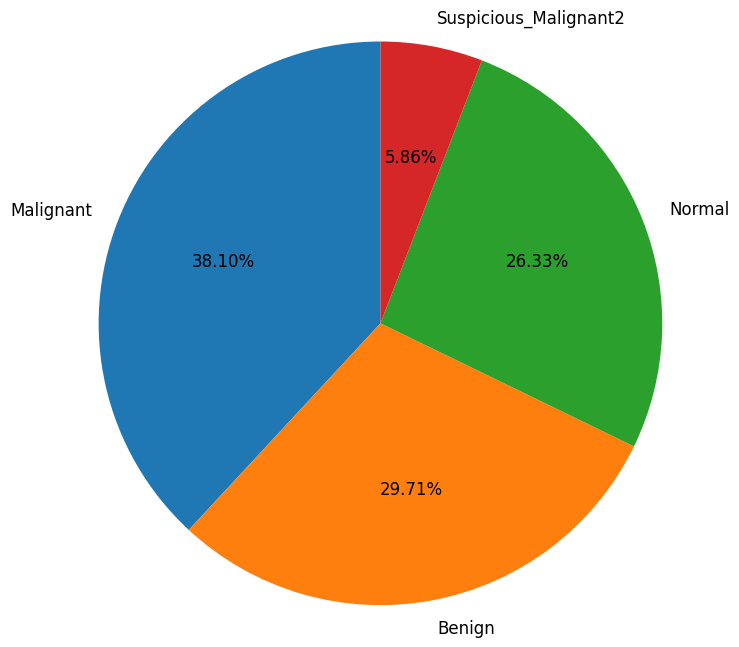

In [9]:
import matplotlib.pyplot as plt
labels = list(class_counts.keys())
sizes = list(class_counts.values())
# creating pie chart
plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize':12}
    
)
plt.axis("equal")  # Make circle shape

plt.show()

In [11]:
plt.savefig(
    r"D:\Thesis_folder\plots_folder\balanced_dataset_distribution.pdf",
    bbox_inches="tight"
)

plt.show()
print(os.listdir(r"D:\Thesis_folder\plots_folder"))

<Figure size 640x480 with 0 Axes>

['balanced_dataset_distribution.pdf', 'Class_distribution_bar_chart.png', 'Class_distribution_ratio_pie_chart.png', 'four_images.png', 'source_dataset_distribution_bar_chart.png', 'source_dataset_pie_chart.png', 'Train_set_class_distribution_pie_chart.png', 'train_test_distribution.png']


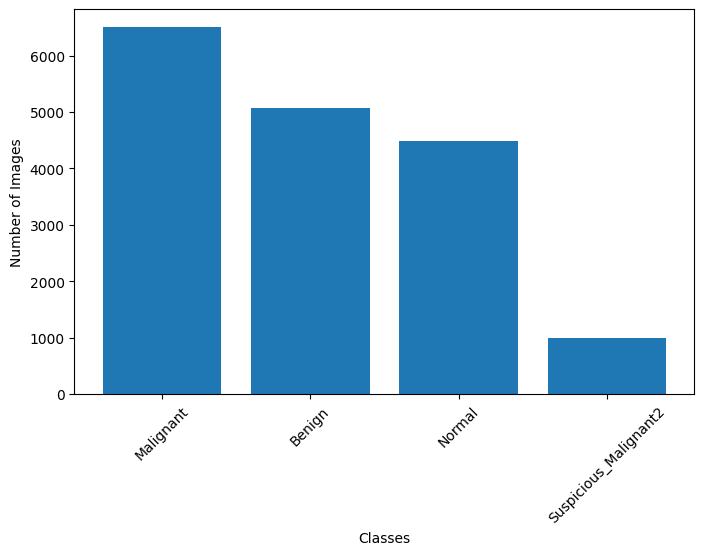

In [14]:
import matplotlib.pyplot as plt

labels = list(class_counts.keys())
sizes = list(class_counts.values())

# Creating bar chart
plt.figure(figsize=(8,5))

plt.bar(
    labels,
    sizes
)

plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()